### Step 1: Data Preparation

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y

df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


#### Explore the dataset

In [2]:
df.describe()
df.isna().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

### Step 2: Simple Linear Regression

#### Train/Test Split

In [3]:
X_single = df[['bmi']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X_single, y, test_size=0.2, random_state=42)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)


#### Evaluation

In [4]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

MAE, MSE, RMSE, R2

(52.25997644534553,
 4061.8259284949268,
 np.float64(63.73245584860925),
 0.23335039815872138)

#### Visualization

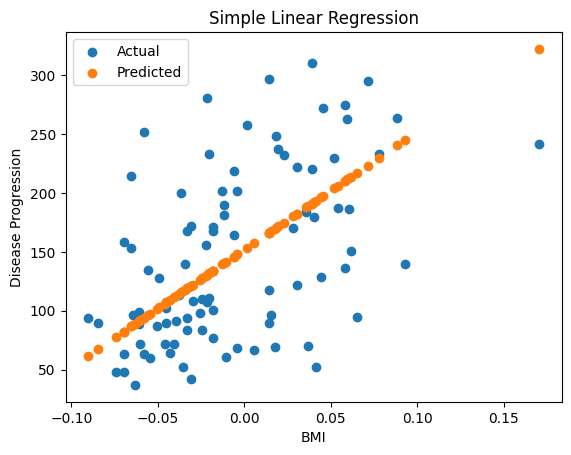

In [5]:
plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred, label="Predicted")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

### Step 3: Multiple Regression

#### Model Training

In [6]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)


#### Evaluation

In [7]:
MAE_multi = mean_absolute_error(y_test, y_pred_multi)
MSE_multi = mean_squared_error(y_test, y_pred_multi)
RMSE_multi = np.sqrt(MSE_multi)
R2_multi = r2_score(y_test, y_pred_multi)

MAE_multi, MSE_multi, RMSE_multi, R2_multi

(42.79409467959994,
 2900.19362849348,
 np.float64(53.853445836765914),
 0.4526027629719197)

#### Visualization

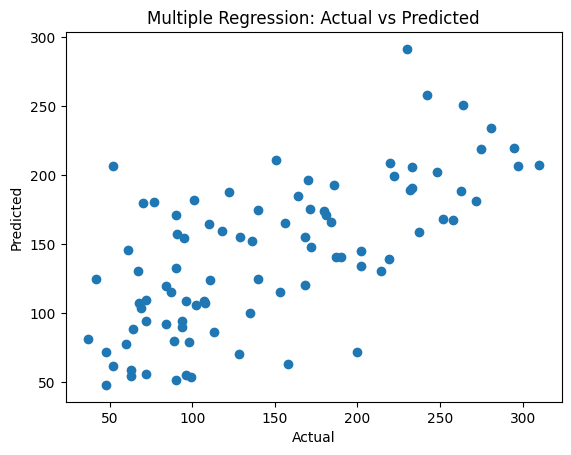

In [8]:
plt.scatter(y_test, y_pred_multi)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Multiple Regression: Actual vs Predicted")
plt.show()


### Step 4: Polynomial Regression

#### Polynomial Degree 2

In [9]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

model_poly = LinearRegression()
model_poly.fit(X_train, y_train)

y_pred_poly = model_poly.predict(X_test)


#### Evaluation

In [10]:
MAE_poly = mean_absolute_error(y_test, y_pred_poly)
MSE_poly = mean_squared_error(y_test, y_pred_poly)
RMSE_poly = np.sqrt(MSE_poly)
R2_poly = r2_score(y_test, y_pred_poly)

MAE_poly, MSE_poly, RMSE_poly, R2_poly


(43.581693254652684,
 3096.028307344274,
 np.float64(55.64196534401237),
 0.41563993364079976)

### Step 5: Regularization (Ridge & Lasso Regression)

#### Ridge Regression

In [11]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

MAE_ridge = mean_absolute_error(y_test, y_pred_ridge)
MSE_ridge = mean_squared_error(y_test, y_pred_ridge)
RMSE_ridge = np.sqrt(MSE_ridge)
R2_ridge = r2_score(y_test, y_pred_ridge)

MAE_ridge, MSE_ridge, RMSE_ridge, R2_ridge


(46.12414580545579,
 3075.1322263562033,
 np.float64(55.45387476413351),
 0.41958396582030866)

#### Lasso Regression

In [12]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

MAE_lasso = mean_absolute_error(y_test, y_pred_lasso)
MSE_lasso = mean_squared_error(y_test, y_pred_lasso)
RMSE_lasso = np.sqrt(MSE_lasso)
R2_lasso = r2_score(y_test, y_pred_lasso)

MAE_lasso, MSE_lasso, RMSE_lasso, R2_lasso


(42.85442771664998,
 2798.1934851697188,
 np.float64(52.897953506442185),
 0.4718547867276227)

#### Visualization

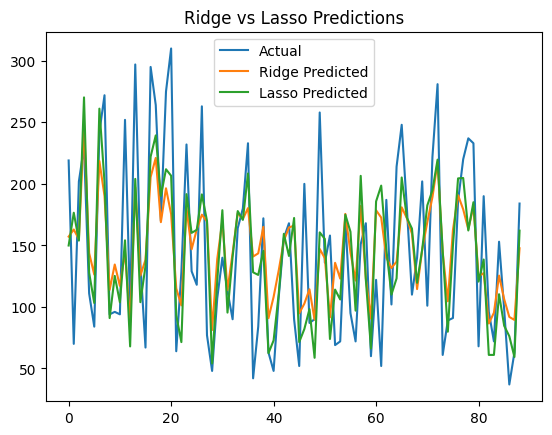

In [13]:
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_ridge, label="Ridge Predicted")
plt.plot(y_pred_lasso, label="Lasso Predicted")
plt.title("Ridge vs Lasso Predictions")
plt.legend()
plt.show()


### Step 6: Model Comparison & Analysis

#### Model Results Summary

The models in this lab were evaluated using four metrics in the following order:

1. Mean Absolute Error (MAE)  
2. Mean Squared Error (MSE)  
3. Root Mean Squared Error (RMSE)  
4. R squared (R²)  

The extracted results from the notebook are:

| Model                    | MAE       | MSE         | RMSE        | R²       |
|--------------------------|-----------|-------------|-------------|----------|
| Simple Linear Regression | 52.2599   | 4061.8259   | 63.7325     | 0.2333   |
| Multiple Regression      | 42.7941   | 2900.1936   | 53.8534     | 0.4526   |
| Polynomial Regression    | 43.5817   | 3096.0283   | 55.6420     | 0.4156   |
| Ridge Regression         | 46.1241   | 3075.1322   | 55.4539     | 0.4196   |
| Lasso Regression         | 42.8544   | 2798.1935   | 52.8980     | 0.4719   |

The following sections summarize and compare these results in detail.

#### Simple Linear Regression

The simple linear regression model used a single feature as the predictor of the diabetes progression target. This model serves as a baseline.

The error values for this model are the highest among all configurations. The MAE of approximately 52.26 and RMSE of about 63.73 indicate that the model predictions deviate substantially from the actual target values on average. The R² value of about 0.23 means the model explains only around 23 percent of the variance in the target variable.

From both the numerical metrics and the corresponding visualization of predicted versus actual values, it is clear that a single feature is not sufficient to capture the complexity of the diabetes dataset. The scatter of points around the regression line remains wide, and the model underfits the data.

#### Multiple Regression

The multiple regression model uses all available features as predictors. This significantly improves performance compared to the simple linear regression model.

The MAE decreases to about 42.79 and RMSE to about 53.85, which shows that the typical prediction error is noticeably reduced. The R² value increases to approximately 0.45, indicating that the model now explains about 45 percent of the variance in the target.

In the visualization of predicted versus actual values, the points tend to concentrate closer to the diagonal reference line. This indicates that adding more features allows the model to capture more of the underlying structure in the data. The improvement over the simple linear regression model highlights that diabetes progression depends on several health indicators rather than on a single factor.

#### Polynomial Regression

The polynomial regression model extends the feature space by including polynomial terms, which allows the model to fit non linear patterns.

The MAE for this model is about 43.58, MSE is about 3096.03, RMSE is about 55.64, and R² is about 0.42. These values are slightly worse than the multiple regression model and similar to the ridge and polynomial based configurations.

Although polynomial features increase model flexibility, the results show that this additional complexity does not translate into a clear improvement on the test set. The small drop in R² compared to multiple regression suggests that the polynomial model starts to fit patterns that do not generalize well, which is a sign of mild overfitting. Visualizations of predicted versus actual values reflect this, with a spread that is comparable to or slightly worse than the multiple regression model.

#### Ridge Regression

Ridge regression applies L2 regularization to the multiple regression setting. This technique shrinks coefficient values toward zero, which helps to reduce the impact of multicollinearity and extreme coefficients.

The ridge model has MAE of about 46.12, MSE of about 3075.13, RMSE of about 55.45, and R² of about 0.42. These results are similar to the polynomial regression model and slightly worse than the plain multiple regression model on this particular test split.

Regularization stabilizes the model and reduces the chance of very large coefficients, but in this case it does not produce a clear gain in performance over multiple regression. This suggests that while there is some correlation among features, it is not severe enough for ridge regularization to provide a large advantage. The corresponding plots show predictions reasonably close to the actual values, but not tighter than the multiple regression model.

#### Lasso Regression

Lasso regression applies L1 regularization, which not only shrinks coefficients but can also drive some of them exactly to zero. This effectively performs feature selection.

The lasso model achieves the best overall performance among all models in this lab. The MAE is about 42.85, MSE is about 2798.19, RMSE is about 52.90, and R² is about 0.47. This is the lowest RMSE and the highest R² value across all configurations, indicating that the lasso model provides the most accurate and best generalizing predictions.

The improvement over multiple regression suggests that some features in the original model may have been noisy or weakly informative. By shrinking or eliminating these features, lasso simplifies the model and focuses on the most relevant predictors. Visualizations of predicted versus actual values show points more closely clustered around the diagonal reference line compared to the other models.

#### Overall Comparison and Conclusions

The progression of results across models shows clear trends in how model complexity and regularization affect performance on the diabetes dataset.

1. Simple linear regression provides a useful baseline but performs poorly, since it relies on only one predictor and leaves most of the variance unexplained.

2. Multiple regression delivers a substantial improvement. By using all features, it reduces both MAE and RMSE and nearly doubles R² compared to the simple linear regression model. This confirms that diabetes progression is influenced by multiple factors.

3. Polynomial regression increases model flexibility by adding non linear terms, but in this experiment it does not outperform multiple regression. The similar or slightly worse metrics indicate that the added complexity introduces a risk of overfitting without yielding better generalization to the test data.

4. Ridge regression stabilizes coefficients and can mitigate multicollinearity, but here its performance is very close to polynomial regression and slightly behind multiple regression. This suggests that the benefit of L2 regularization is limited in this specific setting.

5. Lasso regression provides the best balance between complexity and generalization. It achieves the lowest RMSE and highest R², indicating the most accurate predictions. Its L1 regularization likely removes less useful features, leading to a simpler and more robust model.

In summary, the analysis shows that including multiple features is crucial for modeling diabetes progression and that appropriate regularization, particularly lasso regression, can further improve performance by controlling overfitting and implicitly selecting the most informative predictors.
